In [95]:
%matplotlib ipympl
%reload_ext tensorboard

# TensorFlow Course from CodeBasics

## What is a neuron?

A neuron in an artificial neural network is a mathematical model that consists of a set of inputs, a set of weights,a bias and an activation function. For learning purpose, let us oversimplify it using an example.

Say you have to predict whether a person takes insurance based on their age, income and education. Mathematically, this can be approximated as:

$$
y = \sum_{i=1}^{n} w_i x_i + b
$$

where w(i) is the i-th weight, x(i) is the i-th independent variable and b is the bias. Graphically, we just drew a line of best fit through the points to be able to predict whether a person will take insurance based on the independent variables.

By drawing this line of best fit, which is basically **logistic regression**, we were able to get values of w(i) and b which help us predict y given a set of values x(i), with satisfactory accuracy.

This line of best fit however may not suitably represent the relationship between y and x(i) (for example when it is a classification problem, the graph will jump suddenly as from a certain threshold).

To draw a better curve of best fit, we use an **activation function**, that is above a certain threshold of **y**, the person will take insurance while below that threshold, he will not take insurance. One example of an activation function that we may use is the **sigmoid function**, also known as the **logit function**. The sigmoid function is given by:

$$
\text{sigmoid}(y) = \frac{1}{1 + e^{-y}}
$$

Overall, given our set of inputs x(i), we will calculate y and then use our sigmoid function to know whether this y leads to the person getting insurance (sigmoid(y) > threshold) or not getting insurance (sigmoid(y) <= throshold). That which has just been described is a neuron!

$$
(\text{age},\ \text{income},\ \text{education})
\;\longrightarrow\;
\underset{\Large \text{neuron}}{
\left(
y = \sum_{i=1}^{n} w_i x_i + b \;\middle|\;
z = \frac{1}{1 + e^{-y}}
\right)
}
\;\longrightarrow\;
0 \leq z \leq 1
$$

### Sigmoid function

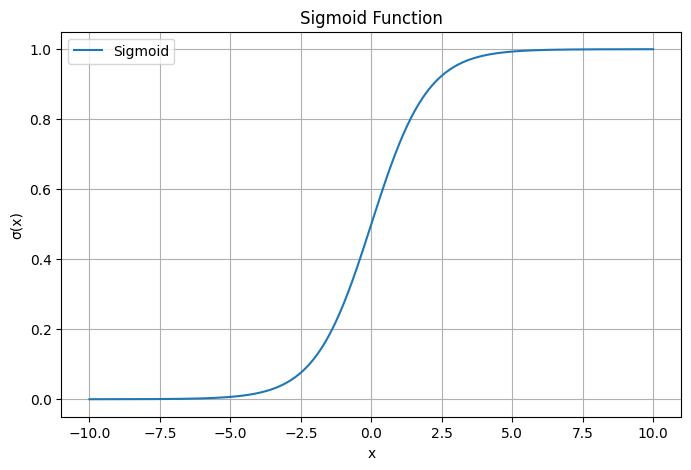

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 400)
y = 1 / (1 + np.exp(-x))

plt.figure(figsize=(8,5))
plt.plot(x, y, label='Sigmoid')
plt.xlabel("x")
plt.ylabel("σ(x)")
plt.title("Sigmoid Function")
plt.grid(True)
plt.legend()
plt.show()

## What is Keras?

Keras was invented as a wrapper for tensorflow, CNTK and theano to make deep learning code simpler. As from TensorFlow 2.0, it has been integrated in the TensorFlow framework itself. 

It has been created for convenience. It is as simple as that.

## Activation Functions

As we have seen, activation functions are helpful in the output layer. For example in binary classification problem, the neuron in the output layer 'firing' may imply that a label is met and it not firing may imply the other label is met. An example of an activation function used in the output layer is the sigmoid function.

However, how are activation functions used in hidden layers?

Consider a neural network with at least 1 hidden layer. The neurons in each hidden layer use an activation function. So each of them apply an activation function on the linear combination of the 'inputs' provided from the previous layer. Say, we remove the activation function for all hidden layers. In this case, the neuron of each hidden layer will only compute a linear combination of the 'inputs' provided by the previous layer. Hence the end result produced at the output layer will only a linear combination of the inputs to the input layer. 

The same result could have been achieved by not using any hidden layers!

**So not using activation functions make the hidden layers totally useless!!**

Most complex problems in real life cannot be simply solved by linear equations. Activation functions help build these non-linear equations.

### Step Function

The simplest (and most useless) example of an activation function is the **step function**. It is shown in the code below.

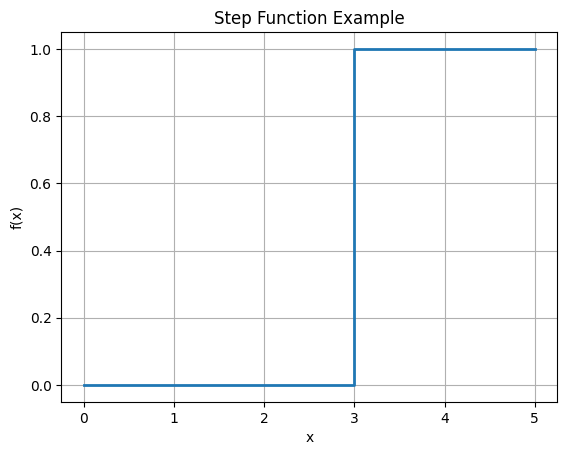

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Example data (step function values)
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 0, 0, 1, 1, 1])

# Create step plot
plt.step(x, y, where='post', linewidth=2)

# Optional styling
plt.title("Step Function Example")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)

plt.show()

A neuron using the step activation function ALWAYS returns either 0 or 1, as we can see in the above graph. The function is discrete.

The step function easily misclassifies some data points.

The second problem with the step function is **multi-class classification**. The step function will always return either 0 or 1. If we look at the MNIST example problem, where we have 10 possible outputs, we will not be able to uniquely identify the output label based on the output of the neurons in the output layer, as we can get a 0 or 1 for more than 2 digits.

### Sigmoid or Logit Function

The sigmoid function, unlike the step function, can return ANY value between 0 and 1 inclusive. Unlike the step function, it is continuous on the interval [0,1].

That is why we were able to use the sigmoid function as the activation function for our output layer in the MNIST problem. The higher the number output by a neuron in the output layer, the greater the probability that would be generated by the softmax function and hence the higher chance that the label of this output layer neuron is our actual digit input to the neural network.

For **binary classification**, it is generally recommended to use sigmoid in the output layer.

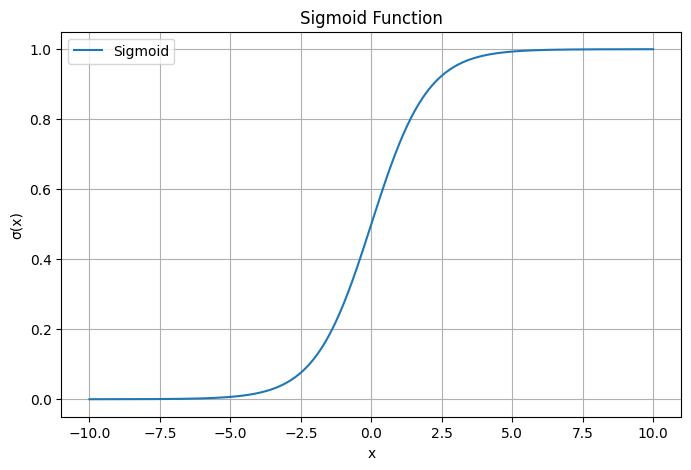

In [4]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 400)
y = 1 / (1 + np.exp(-x))

plt.figure(figsize=(8,5))
plt.plot(x, y, label='Sigmoid')
plt.xlabel("x")
plt.ylabel("σ(x)")
plt.title("Sigmoid Function")
plt.grid(True)
plt.legend()
plt.show()

### The tanh function

It is similar to the sigmoid function but instead of giving a range of [0,1], it gives a range of (-1,1).

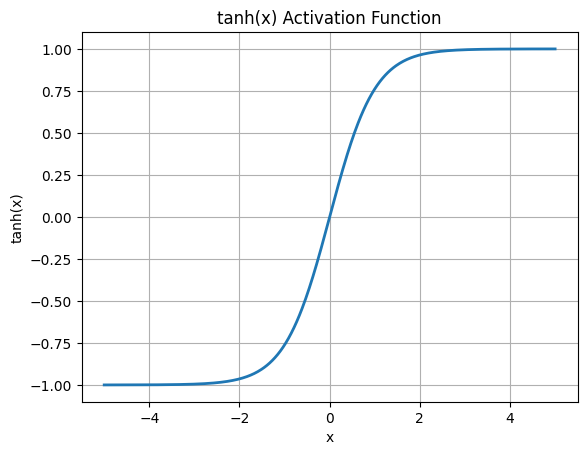

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Input range
x = np.linspace(-5, 5, 500)

# tanh activation function
y = np.tanh(x)

# Plot
plt.plot(x, y, linewidth=2)

# Styling
plt.title("tanh(x) Activation Function")
plt.xlabel("x")
plt.ylabel("tanh(x)")
plt.grid(True)

plt.show()

The tanh function is usually used in layers except for the output layer *(need to research on this)*.

### The issues with the sigmoid function and the tanh function

In the gradient descent algorithm, you need to calculate the derivative of your activation function and use them to backpropagate your errors. However, for both the sigmoid function and the tanh function, the derivate for small and large values are nearly 0, as we can decipher by their graphs.

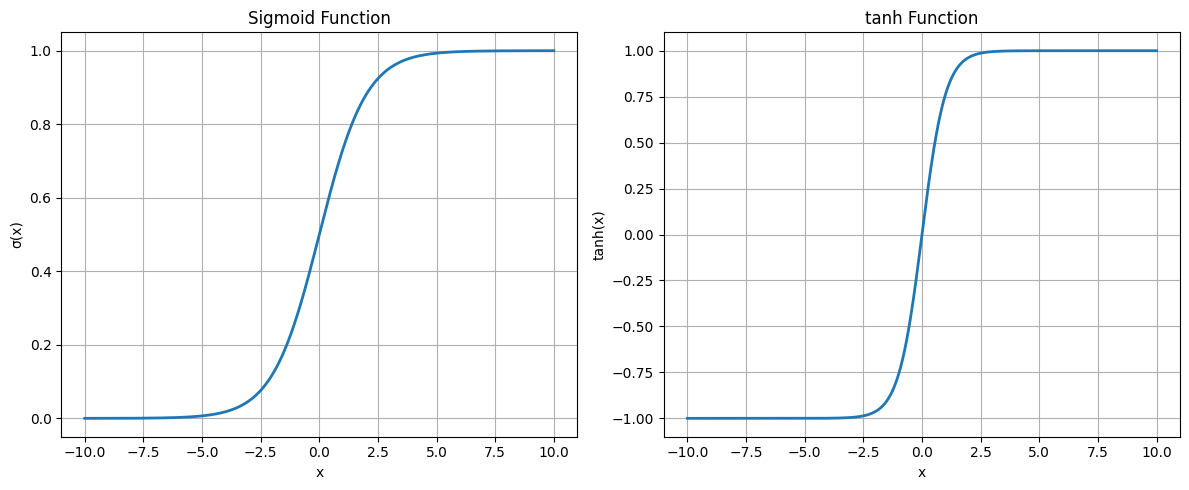

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Input range
x = np.linspace(-10, 10, 500)

# Activation functions
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sigmoid plot
axes[0].plot(x, sigmoid, linewidth=2)
axes[0].set_title("Sigmoid Function")
axes[0].set_xlabel("x")
axes[0].set_ylabel("σ(x)")
axes[0].grid(True)

# Tanh plot
axes[1].plot(x, tanh, linewidth=2)
axes[1].set_title("tanh Function")
axes[1].set_xlabel("x")
axes[1].set_ylabel("tanh(x)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Due to these near-zero gradients, the learning of the Neural Network becomes very, very slow. This is called the **vanishing gradient problem**.


To solve this problem, we came up with the **relu function**.

### The ReLu Function

The Relu function is basically:

$$
\text{ReLU}(z) = \max(0, z)
$$

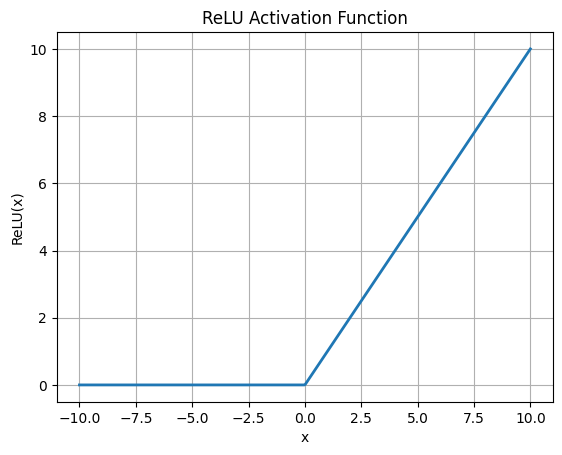

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Input range
x = np.linspace(-10, 10, 500)

# ReLU function
relu = np.maximum(0, x)

# Plot
plt.plot(x, relu, linewidth=2)

# Styling
plt.title("ReLU Activation Function")
plt.xlabel("x")
plt.ylabel("ReLU(x)")
plt.grid(True)

plt.show()

Basically, if our input is less than or equal to 0, the output is 0. If our input is greater than 0, our output is zero.

>**THE GUIDELINE IS: FOR HIDDEN LAYERS, IF YOU ARE UNSURE WHICH ACTIVATION FUNCTION TO USE, JUST USE ReLU AS YOUR DEFAULT CHOICE**

Given the simplicity of the function, it is very computationally inexpensive.

ReLU also has the vanishing gradient problem for inputs less than 0. Hence to solve that problem we have the **Leaky ReLU**

## Leaky ReLU

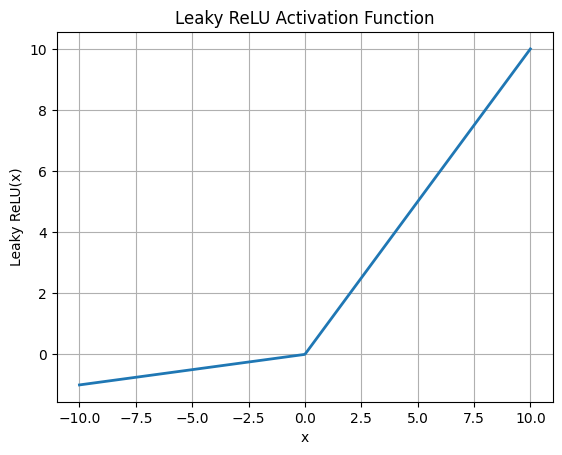

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Input range
x = np.linspace(-10, 10, 500)

# Leaky ReLU parameter (small slope for negative values)
alpha = 0.1

# Leaky ReLU function
leaky_relu = np.where(x > 0, x, alpha * x)

# Plot
plt.plot(x, leaky_relu, linewidth=2)

# Styling
plt.title("Leaky ReLU Activation Function")
plt.xlabel("x")
plt.ylabel("Leaky ReLU(x)")
plt.grid(True)

plt.show()

In Leaky ReLU, we are trying to remove the zero gradient for input values less than 0. The equation can be the following for example:

$$
\text{Leaky ReLU}(z) = \max(0.1z, z)
$$

### Summary of Activation Function

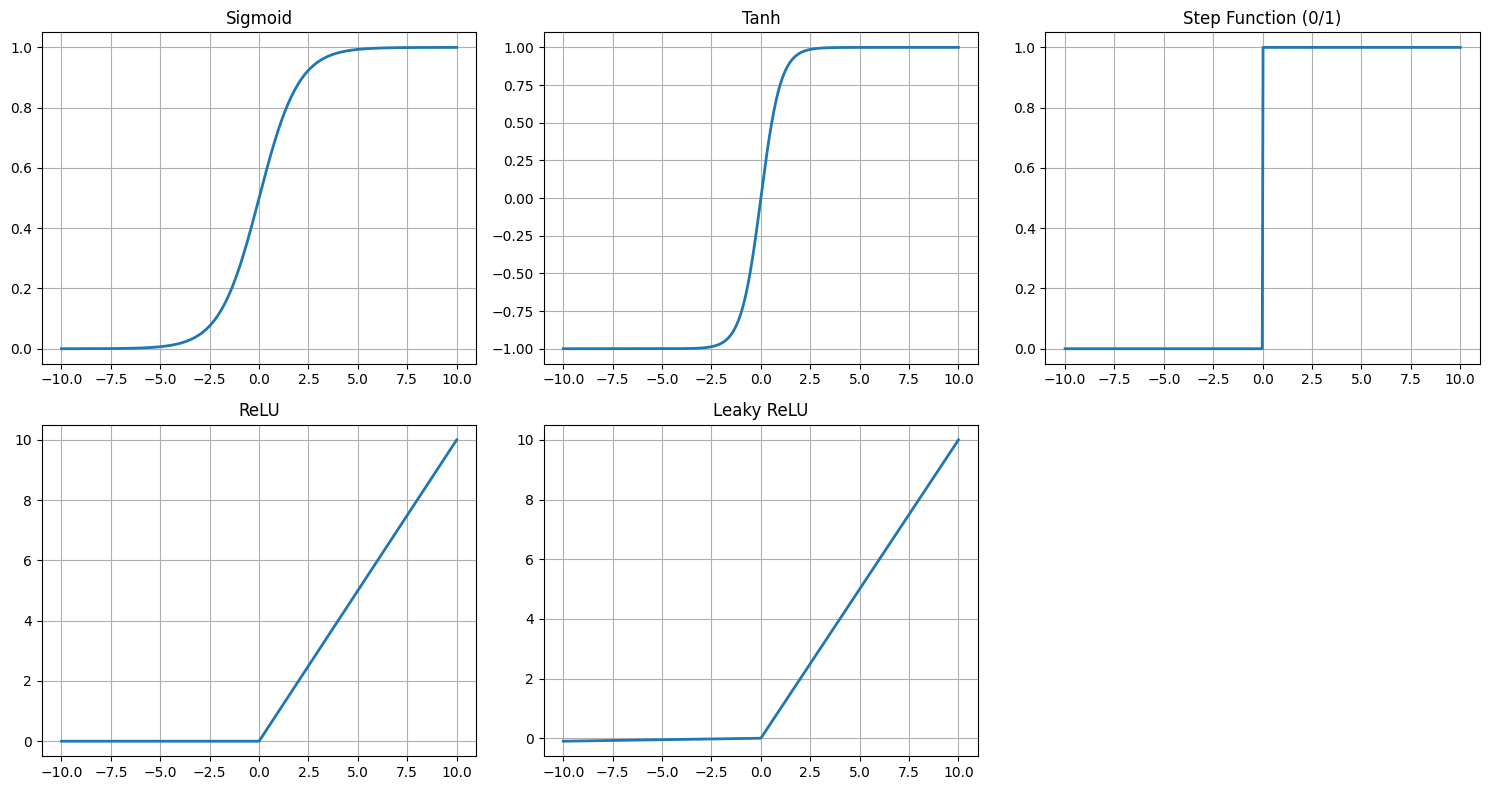

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Input range
x = np.linspace(-10, 10, 500)

# Activation functions
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

alpha = 0.01
leaky_relu = np.where(x > 0, x, alpha * x)

# Step function (Heaviside)
step = np.where(x >= 0, 1, 0)

# Create subplots (2x3 grid)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Sigmoid
axes[0, 0].plot(x, sigmoid, linewidth=2)
axes[0, 0].set_title("Sigmoid")
axes[0, 0].grid(True)

# Tanh
axes[0, 1].plot(x, tanh, linewidth=2)
axes[0, 1].set_title("Tanh")
axes[0, 1].grid(True)

# Step function
axes[0, 2].plot(x, step, linewidth=2)
axes[0, 2].set_title("Step Function (0/1)")
axes[0, 2].grid(True)

# ReLU
axes[1, 0].plot(x, relu, linewidth=2)
axes[1, 0].set_title("ReLU")
axes[1, 0].grid(True)

# Leaky ReLU
axes[1, 1].plot(x, leaky_relu, linewidth=2)
axes[1, 1].set_title("Leaky ReLU")
axes[1, 1].grid(True)

# Empty last subplot (optional cleanup)
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

The choice of which activation function to use is not always clear. 

- For binary classification problems, we would most likely use the sigmoid function in the output layer.
- For the hidden layers, we would most likely use ReLU or Leaky ReLU.
- For linear/non-linear regression, we generally do not use an activation function in the output layer, as the output should be a linear combination of the input (such as predicting house prices). We usually use the ReLU activation function for the hidden layers.

## Loss or Cost Functions

Loss functions are used to calculate the loss between the actual value and the predicted value. Different loss functions relate to different mathematical formulae used to calculate the loss. Example of loss functions are:

- Sparse Categorical Crossentropy
- Binary Crossentropy
- Categorical Crossentropy
- Mean Absolute Error
- Mean Squared Error

*NOTE: Individual errors are called losses while the aggregated error is called the cost.*

---

### Mean Absolute Error

The formula for mean absolute error is:

$$
MAE = \frac{1}{n}\sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|
$$

We use MAE for:

- linear regression
- care about average error magnitude, not large penalties
- data with outliers(MAE is more robust)

Difference from MSE:

- MSE heavily punishes big mistakes
- MAE treats all errors linearly

Trade-off:

- MAE is more stable but harder to optimize (gradient is constant)

It is a bad choice for:

- Classification problems/logistic regression

---

### Mean Squared Error

The formula for mean squared error is:

$$
\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

We use MSE for:

- linear regression problems
- penalizing large errors more than small ones (because of squaring)

It is a bad choice for:

- Classification problems(it treats classes like numbers which is wrong)

---

### Binary Crossentropy or Log Loss

The formula for binary crossentropy is:

$$
\text{Binary Crossentropy}
= -\frac{1}{n}\sum_{i=1}^{n}
\left[
y_i \log(p_i) + (1 - y_i)\log(1 - p_i)
\right]
$$

**Where**

$$
n = \text{number of samples}
$$

$$
i = \text{index of a sample, } i = 1,2,\dots,n
$$

$$
y_i \in \{0,1\} = \text{true binary label for sample } i
$$

$$
p_i \in (0,1) = \text{predicted probability that sample } i \text{ belongs to class } 1
$$

$$
\log = \text{natural logarithm (base } e \text{)}
$$

It is used for:

- Binary Classification (two classes only)
- Output layer is 1 neuron with sigmoid
- Output probability of class 1

Example use cases:

- spam v/s not spam
- disease v/s no disease
- yes/no predictions

Why it works:

- Directly models probability mismatch
- Strongly penalizes confident wrong predictions

---

### Categorical Crossentropy

The formula for categorical crossentropy is:

$$
\text{Categorical Crossentropy}
= -\frac{1}{n}\sum_{i=1}^{n}\sum_{k=1}^{K}
y_{i,k}\log(p_{i,k})
$$

**where**

$$
n = \text{number of samples}
$$

$$
i = \text{index of a sample, } i = 1,2,\dots,n
$$

$$
K = \text{number of classes}
$$

$$
k = \text{class index, } k = 1,2,\dots,K
$$

$$
y_{i,k} \in \{0,1\} = \text{one-hot encoded true label for sample } i \text{ and class } k
$$

$$
p_{i,k} \in (0,1) = \text{predicted probability that sample } i \text{ belongs to class } k
$$

$$
\log = \text{natural logarithm (base } e \text{)}
$$

It should be used:

- For multi-class classification (one correct class)
- When the output layer uses softmax over K classes
- When labels are one-hot encoded

Typical use cases:

- digit recognition
- object classification(cat,dog,bird)

Key idea:

- Compares full probability distribution v/s true class distribution

---

### Sparse Categorical Crossentropy

The formula for sparse categorical crossentropy is:
$$
\text{Sparse Categorical Crossentropy}
= -\frac{1}{n}\sum_{i=1}^{n}\log\left(p_{i, y_i}\right)
$$

**Where**

$$
n = \text{number of samples}
$$

$$
i = \text{index of a sample, } i = 1,2,\dots,n
$$

$$
y_i \in \{0,1\} = \text{true binary label for sample } i
$$

$$
p_i \in (0,1) = \text{predicted probability that } y_i = 1
$$

$$
\log = \text{natural logarithm (base } e \text{)}
$$

It is the same as categorical crossentropy, but with a different label format.

It is used when:

- we have multi-class definitions
- but labels are **integers** instead of one-hot vectors

Example:

- label = 3 instead of [0,0,0,1,0]

It is useful as:

- saves memory
- easier preprocessing

Internally, it behaves exactly like categorical crossentropy

---

### Sparse Categorical Crossentropy vs Categorical Crossentropy (Use Cases)

The difference is only in how labels are represented, not in the underlying idea.



#### 1. Categorical Crossentropy (One-Hot Labels)

##### Use case: Image classification (10 classes: digits 0–9)

You use this when labels are **one-hot encoded vectors**.

##### Dataset format

| Image     | Label (one-hot)                  |
|----------|----------------------------------|
| image_1  | [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]   |
| image_2  | [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]   |
| image_3  | [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]   |

##### Model output (softmax)

$$
[0.1,\ 0.05,\ 0.7,\ 0.02,\ \dots]
$$

##### Loss function
- Categorical Crossentropy

##### When to use
- Labels already converted to one-hot vectors
- Multi-class problems with explicit vector encoding



#### 2. Sparse Categorical Crossentropy (Integer Labels)

##### Use case: Same image classification task (10 classes)

You use this when labels are **integer encoded**.

##### Dataset format

| Image     | Label (integer) |
|----------|-----------------|
| image_1  | 2               |
| image_2  | 5               |
| image_3  | 0               |

##### Model output (softmax)

$$
[0.1,\ 0.05,\ 0.7,\ 0.02,\ \dots]
$$

##### Loss function
- Sparse Categorical Crossentropy

##### When to use
- Labels stored as integers
- Default choice in most modern pipelines (e.g., TensorFlow/Keras)
- Large number of classes where one-hot encoding is inefficient



#### Summary

| Loss Function                     | Label Format        | Example Label |
|----------------------------------|---------------------|--------------|
| Categorical Crossentropy         | One-hot vector      | [0,0,1,0,...] |
| Sparse Categorical Crossentropy  | Integer class index  | 2, 5, 0       |



#### Practical takeaway

If you are unsure:
- Use **Sparse Categorical Crossentropy**
- Only switch to categorical if your pipeline already uses one-hot encoding

## Gradient Descent for Neural Networks

Gradient descent is used during the training of a neural network. Say we are trying to predict the continuous prediction target y, based on the predictors $x_1$ and $x_2$.

We can use a linear regression model to try to ascertain the weights $w_1$ and $w_2$, such that:

$$

y = w_1*x_1 +w_2*x_2 + b
$$

where b is the bias.

Say after training your linear regression neural network for 1 epoch, you get a MAE of 4.31, which is considered a large error. In that case, you will need to adjust the weights $w_1$ and $w_2$ according to your loss. 

Basically you need to do:

$$

w_1 = w_1 - something

$$

The derivative of your loss compared to $w_1$ indicates **how your loss changes for a given change in $w_1$**. If we let L be the loss and let the derivative of L compared to $w_1$ be:

$$
\frac{\partial L}{\partial W_1}
$$

Then we can choose our new value of $w_1$ to be:

$$
W_1 = W_1 - \eta \frac{\partial L}{\partial W_1}
$$

where $\eta$ is the learning rate.


Why are we substracting? This is because we ALWAYS need to move in opposite direction to gradient in order to read a local maxima/minima!!

- If gradient is positive, our movement should be in negative x-direction (in 2D).
- If gradient is negative, our movement should be in positive x-direction (in 2D)


Consider the very simple plot of loss against w_1 below:

interactive(children=(FloatSlider(value=2.0, description='w', max=8.0), Output()), _dom_classes=('widget-inter…

<function __main__.update(w)>

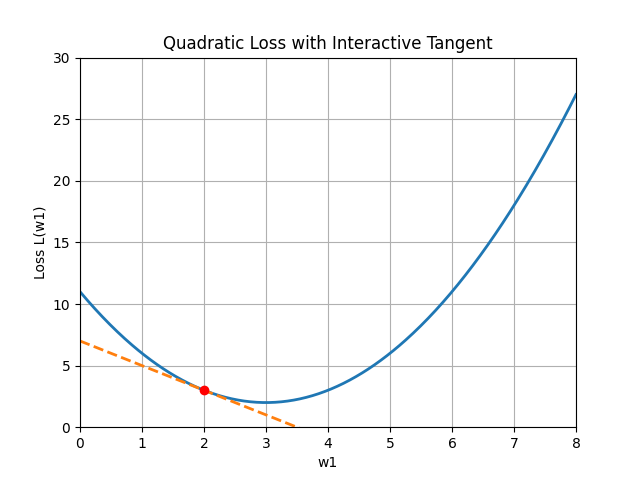

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets

# Quadratic loss function
def loss(w1):
    return (w1 - 3)**2 + 2

def dloss(w1):
    return 2 * (w1 - 3)

w1 = np.linspace(0, 8, 400)

fig, ax = plt.subplots()

ax.set_xlim(0, 8)
ax.set_ylim(0, 30)
ax.set_xlabel("w1")
ax.set_ylabel("Loss L(w1)")
ax.set_title("Quadratic Loss with Interactive Tangent")
ax.grid(True)

# Base curve
ax.plot(w1, loss(w1), linewidth=2)

# Initial tangent
w_init = 2
L_init = loss(w_init)
slope = dloss(w_init)

tangent_line, = ax.plot(w1, L_init + slope*(w1 - w_init), '--', linewidth=2)
point, = ax.plot([w_init], [L_init], 'ro')

def update(w):
    Lw = loss(w)
    m = dloss(w)
    
    tangent_line.set_ydata(Lw + m*(w1 - w))
    point.set_data([w], [Lw])
    
    fig.canvas.draw_idle()

widgets.interact(update, w=widgets.FloatSlider(min=0, max=8, step=0.1, value=w_init))

As we can see, for any value of $w_1$, moving against the gradient leads us to the local minima (for the above case). 

The learning rate controls how big of a step we take against the gradient after each epoch. Too big a learning rate may lead to us always 'stepping over' the local point. Too small a learning rate means that we will take a lot of time to reach the local point.

So we do apply the same formula to both w_2 and b, as shown below:

$$
W_2 = W_2 - \eta \frac{\partial L}{\partial W_2}
$$

$$
b = b - \eta \frac{\partial L}{\partial b}
$$

We are, at the end of each epoch, calculating the value of $\frac{\partial L}{\partial W_1}$ , $\frac{\partial L}{\partial W_2}$ and $\frac{\partial L}{\partial b}$ for our value of L calculated at the end of the current epoch, and then we adjust our weights $w_1$ and $w_2$, and our bias to bring the calculated loss closer to its closest local point


The formula for  $\frac{\partial L}{\partial W_1}$ , $\frac{\partial L}{\partial W_2}$ and $\frac{\partial L}{\partial b}$ depends on the **loss function we have chosen**.

### Example code to understand Gradient Descent better

In [5]:
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
import pandas as pd
import sklearn

In [9]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten


# Read the dataframe
df = pd.read_csv("./datasets/insurance_data.csv")

# Split the data into training data and test data
X_train, X_test, y_train, y_test = train_test_split(df[["age", "affordibility"]], df["bought_insurance"], test_size=0.2)

# Scale the age predictor
X_train_scaled = X_train.copy()
X_train_scaled["age"] = X_train["age"] / 100

X_test_scaled = X_test.copy()
X_test_scaled["age"] = X_test["age"] / 100

# Build the neural network architecture
model = Sequential()

# Input layer
model.add(Input((2,)))
# Flatten the input (not really necessary here)
model.add(Flatten())
# Output layer
model.add(Dense(1, 
                activation="sigmoid",
                kernel_initializer='ones',
                bias_initializer='zeros'))

<details>
As we can see in the above code, our neural network simply has 1 input layer and 1 output layer - it has no hidden layers. We have used the *sigmoid activation* function for the output layer as this is a binary classification problem. Our output layer also only has 1 neuron as this is a **binary** classification.

*kernel_initializer* and *bias_initializer* are used to initialize the weights and biases of the neurons in each layer, before learning starts. The weights and biases of every layer should be initialized except for the input layer, as no processing is done at the input layer - it simply inputs the data to the neural network.

In the above case, we are setting the weights of the neuron in the output layer to 1 and its bias to 0 at the start of training.

In [11]:
# Set the hyperparameters of our NN
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train_scaled, y_train, epochs=5000)

Epoch 1/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 0.7658
Epoch 2/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.5000 - loss: 0.7653
Epoch 3/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.5000 - loss: 0.7649
Epoch 4/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.5000 - loss: 0.7644
Epoch 5/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.5000 - loss: 0.7640
Epoch 6/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.5000 - loss: 0.7635
Epoch 7/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5000 - loss: 0.7630
Epoch 8/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5000 - loss: 0.7626
Epoch 9/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5000 - loss: 0.7621
Epoch 10/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.5000 - loss: 0.7617
Epoch 11/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5000 - loss: 0.7612
Epoch 12/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accur

In [12]:
model.evaluate(X_test_scaled, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8333 - loss: 0.3802


[0.38020822405815125, 0.8333333134651184]

Now that we have trained the model, we would like to know the final weights and bias that the model is using to predict the y based on the input values.

In [17]:
weights, bias = model.get_weights()
weights, bias

(array([[5.3555646 ],
        [0.70623386]], dtype=float32),
 array([-2.5784645], dtype=float32))

As we can see, the value of $w_1$ and $w_2$ are 5.3555646 and 0.70623386 respectively. The value of bias used by the model is -2.5784645

However, to truly understand what is happening, let us try to create the neural network, using our weights and bias calculated, without using tensorflow.

In [ ]:
# Our sigmoid activation function
def sigmoid(z: float) -> float:
    import math
    return 1 / (1 + math.exp(-z))

# Our prediction function
def prediction_function(age: float, affordibility: int) -> float:
    weighted_sum = (weights[0] * age + weights[1] * affordibility + bias)[0] # [weighted_sum][0]
    return sigmoid(weighted_sum)

# Let us try our prediction function to see if it gives the same
# result as our neural network
prediction_function(0.47,1)

0.6558567918125208

As we can see, the sigmoid function output is above our threshold of of 0.5, meaning the person will buy insurance, which is consitent with the actual output in the csv file.

In [23]:
# Binary crossentropy loss/ log loss
def log_loss(y_true, y_predicted):
    epsilon = 1e-15
    y_predicted_new = [max(i,epsilon) for i in y_predicted]
    y_predicted_new = [min(i,1-epsilon) for i in y_predicted_new]
    y_predicted_new = np.array(y_predicted_new)
    return -np.mean(y_true*np.log(y_predicted_new)+(1-y_true)*np.log(1-y_predicted_new))

# Sigmoid function for numpy format
def sigmoid_numpy(Z):
    return 1/(1+np.exp(-Z))

# Our gradient descent algorithm
# age = X_train_scaled['age']
# affordibility = X_train_scaled['affordibility']
# We can optionally pass a loss threshold to stop our loop when our 
# loss becomes less than the loss we obtained from our tensorflow model
def gradient_descent(age, affordibility, y_true, epochs, loss_thresold):
    # kernel_initializer = 'ones'
    w1=w2=1
    # bias_initializer = 'zeros'
    bias = 0
    learning_rate = 0.5
    number_of_training_data_per_epoch = len(age)

    for i in range(epochs):
        # Output layer neuron
        weighted_sum = w1*age + w2*affordibility + bias
        y_predicted = sigmoid_numpy(weighted_sum)

        # Calculate the loss
        loss = log_loss(y_true, y_predicted)

        # Calculate the derivatives
        w1_derivative_with_respect_to_loss = (1/number_of_training_data_per_epoch)*np.dot(np.transpose(age),(y_predicted-y_true))
        w2_derivative_with_respect_to_loss = (1/number_of_training_data_per_epoch)*np.dot(np.transpose(affordibility),(y_predicted-y_true))
        bias_derivative_with_respect_to_loss = np.mean(y_predicted-y_true)

        # Adjust the values of w1, w2 and bias
        w1 = w1 - learning_rate * w1_derivative_with_respect_to_loss
        w2 = w2 - learning_rate * w2_derivative_with_respect_to_loss
        bias = bias - learning_rate * bias_derivative_with_respect_to_loss

        print(f"Epoch: {i+1}, w1:{w1}, w2:{w2}, bias:{bias}, loss:{loss}")

        if loss <= loss_thresold:
            break

    return w1, w2, bias

gradient_descent(X_train_scaled['age'], X_train_scaled['affordibility'], y_train, 1000, 0.4680)


Epoch: 1, w1:0.9764449150147355, w2:0.913150872975842, bias:-0.12197852992921243, loss:0.765802847654102
Epoch: 2, w1:0.9597297856526217, w2:0.8396934772977124, bias:-0.2262365385897972, loss:0.7232739882595339
Epoch: 3, w1:0.9493335025144143, w2:0.7788218919793156, bias:-0.3141955172983783, loss:0.6928773610724149
Epoch: 4, w1:0.944535012688322, w2:0.7292363196960332, bias:-0.38776010221684576, loss:0.6717692589431254
Epoch: 5, w1:0.9445319899688881, w2:0.6894041143964529, bias:-0.4490155293463009, loss:0.6573850320551435
Epoch: 6, w1:0.948533296218469, w2:0.6577698531345648, bias:-0.499997257533321, loss:0.6476588384375432
Epoch: 7, w1:0.9558155568613667, w2:0.6328881851347137, bias:-0.5425535134210278, loss:0.6410551239061116
Epoch: 8, w1:0.9657491184881186, w2:0.6134887627931906, bias:-0.5782850270354604, loss:0.6364954464303811
Epoch: 9, w1:0.9778035014719159, w2:0.5984947987120476, bias:-0.6085354169995296, loss:0.6332517961788819
Epoch: 10, w1:0.9915414350651661, w2:0.5870152130

(np.float64(5.365873300068941),
 np.float64(0.7105838162359919),
 np.float64(-2.5858598488691333))

As we can see, our gradient descent algorithm produces weights and a bias that is very close to what tensorflow had produced internally using the Sequential model!!!

This is gradient descent.

### Building the Neural Network from Scratch!

Let us create our neural network class, its fit() methods and predict() method.

In [ ]:
class MyNeuralNetwork():

    def __init__(self):
        self._w1 = 1
        self._w2 = 1
        self._bias = 0

    def _gradient_descent(self, age, affordibility, y_true, epochs, loss_thresold):
        # kernel_initializer = 'ones'
        w1=self._w1
        w2=self._w2
        # bias_initializer = 'zeros'
        bias = self._bias
        learning_rate = 0.5
        number_of_training_data_per_epoch = len(age)

        for i in range(epochs):
            # Output layer neuron
            weighted_sum = w1*age + w2*affordibility + bias
            y_predicted = sigmoid_numpy(weighted_sum)

            # Calculate the loss
            loss = log_loss(y_true, y_predicted)

            # Calculate the derivatives
            w1_derivative_with_respect_to_loss = (1/number_of_training_data_per_epoch)*np.dot(np.transpose(age),(y_predicted-y_true))
            w2_derivative_with_respect_to_loss = (1/number_of_training_data_per_epoch)*np.dot(np.transpose(affordibility),(y_predicted-y_true))
            bias_derivative_with_respect_to_loss = np.mean(y_predicted-y_true)

            # Adjust the values of w1, w2 and bias
            w1 = w1 - learning_rate * w1_derivative_with_respect_to_loss
            w2 = w2 - learning_rate * w2_derivative_with_respect_to_loss
            bias = bias - learning_rate * bias_derivative_with_respect_to_loss

            if (i+1) % 50 == 0:
                print(f"Epoch: {i+1}, w1:{w1}, w2:{w2}, bias:{bias}, loss:{loss}")

            if loss <= loss_thresold:
                print(f"Epoch: {i+1}, w1:{w1}, w2:{w2}, bias:{bias}, loss:{loss}")
                break

        return w1, w2, bias
    
    def fit(self, X, y, epochs, loss_threshold):
        self._w1, self._w2, self._bias = self._gradient_descent(X["age"], X["affordibility"], y, epochs, loss_threshold)

    def predict(self, X_test):
        weighted_sum = self._w1 * X_test["age"] + self._w2 * X_test["affordibility"] + self._bias 

        return sigmoid_numpy(weighted_sum)

In [35]:
customModel = MyNeuralNetwork()
customModel.fit(X_train_scaled, y_train, epochs=500, loss_threshold=0.4631)

Epoch: 50, w1:1.7413693180324925, w2:0.5936475160337356, bias:-1.0497420642228465, loss:0.5919801520708845
Epoch: 100, w1:2.6156829487146287, w2:0.6331375165611548, bias:-1.4307571009386948, loss:0.5553546883751256
Epoch: 150, w1:3.395871312421618, w2:0.6579128678862234, bias:-1.7613865956206114, loss:0.5264763853400205
Epoch: 200, w1:4.093159256043415, w2:0.6767524717915627, bias:-2.053673393486734, loss:0.5034956116779853
Epoch: 250, w1:4.718349911292204, w2:0.6930986592076498, bias:-2.314981282949321, loss:0.48504209245017976
Epoch: 300, w1:5.281064853004731, w2:0.7082380016448588, bias:-2.5503456597348007, loss:0.47009182811070765


In [36]:
customModel.predict(X_test_scaled)

5     0.762142
18    0.166094
23    0.634492
3     0.556065
15    0.751894
1     0.217679
dtype: float64

In [37]:
model.predict(X_test_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 620ms/step


array([[0.7552636 ],
       [0.1735165 ],
       [0.63129425],
       [0.55142474],
       [0.74522966],
       [0.22451025]], dtype=float32)

As we can see, our custom model gives approximately the same output as our tensorflow model.

## Stochastic Gradient Descent v/s Batch Gradient Descent v/s  Mini Batch Gradient Descent

The gradient descent algorithm that we had been using till now is known as **batch gradient descent**. In batch gradient descent,

- we go through all the training samples in each epoch, and calculate the cumulative error
- then, we backprobagate and adjust the weights

What if we have **10 million samples** now?

- To find the cumulative error for first round (epoch), we need to do a forward pass for 10 million samples in each epoch.
- For n features, this will require 10n million derivatives!

This is crazy computation. 

It can take 2 years to train a model with lots of weights and my computer may even crash (WOMP WOMP)

So, in such a scenario, we can use **stochasctic gradient descent**.

For stochastic gradient descent,

- we use one **randomly picked** sample for a forward pass and the adjust the weights and bias.
- it is good when the training set is very large and we don't want too much computation

Batch gradient descent is ,on the other hand, on small training set if computation power is limited.

**NOTE: In tensorflow, we specify the gradient descent algorithm to use using the 'optimizer' parameter of model.compile()**

Below are graphs comparing how the cost varies against epoch for both algorithms.

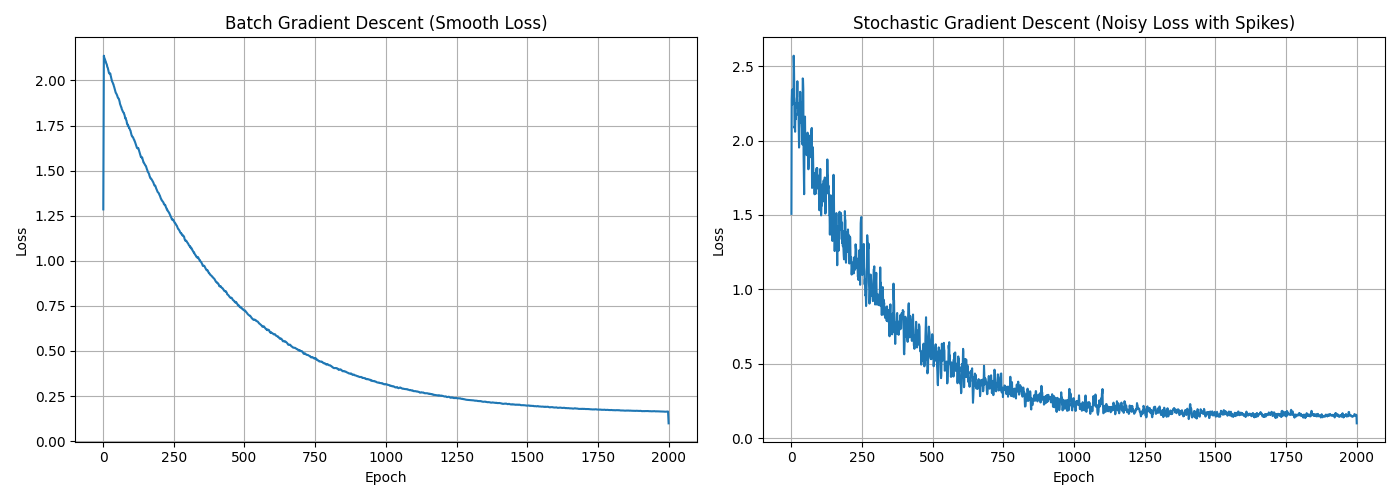

In [41]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(10)

epochs = np.arange(1, 2001)

# ----------------------------
# Batch Gradient Descent (smooth)
# ----------------------------
batch_base = 2.0 * np.exp(-epochs / 400) + 0.15
batch_noise = 0.01 * np.exp(-epochs / 800) * np.random.randn(len(epochs))
batch_cost = batch_base + batch_noise

# light smoothing effect (typical of full-batch stability)
batch_cost = np.convolve(batch_cost, np.ones(5)/5, mode='same')

# ----------------------------
# Stochastic Gradient Descent (noisy + spikes)
# ----------------------------
sgd_base = 2.2 * np.exp(-epochs / 300) + 0.15

# decaying noise (high variance early, lower later)
sgd_noise = (0.25 * np.exp(-epochs / 600)) * np.random.randn(len(epochs))

sgd_cost = sgd_base + sgd_noise

# add occasional upward spikes (mini-batch "bad luck")
num_spikes = 60
spike_idx = np.random.choice(len(epochs), num_spikes, replace=False)

for i in spike_idx:
    spike_magnitude = np.random.uniform(0.2, 0.8) * np.exp(-i / 800)
    sgd_cost[i] += spike_magnitude

# prevent absurd negatives but keep fluctuations
sgd_cost = np.clip(sgd_cost, 0.1, None)

# slight smoothing to mimic real training logs (optional)
sgd_cost = np.convolve(sgd_cost, np.ones(3)/3, mode='same')

# ----------------------------
# Plot side by side
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, batch_cost)
axes[0].set_title("Batch Gradient Descent (Smooth Loss)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

axes[1].plot(epochs, sgd_cost)
axes[1].set_title("Stochastic Gradient Descent (Noisy Loss with Spikes)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Mini batch gradient descent** is like Stochastic Gradient descent(SDG). However, instead of choosing 1 random training sample, you will use a batch of randomly picked training sample suring each epoch.

| Feature | Batch Gradient Descent | Stochastic Gradient Descent (SGD) | Mini-batch Gradient Descent |
|--------|------------------------|------------------------------------|------------------------------|
| Data used per update | Entire dataset | One training example | Small subset (e.g., 16–256 samples) |
| Update frequency | Once per epoch | Every training example | Multiple updates per epoch |
| Speed per update | Slow | Very fast | Fast |
| Memory usage | High | Low | Moderate |
| Gradient stability | Very stable | Very noisy | Moderately noisy |
| Convergence behaviour | Smooth but can be slow | Fast but erratic | Balanced and stable |
| Loss curve shape | Smooth downward curve | Noisy with spikes and fluctuations | Mostly smooth with small noise |
| Risk of getting stuck in local minima | Higher | Lower (noise helps escape) | Medium |
| Parallelization efficiency | High | Low | High |
| Typical use cases | Small datasets, convex optimisation | Online learning, very large datasets | Deep learning (standard choice) |

<details>

“Online learning” means the model is trained continuously as new data arrives, rather than being trained once on a fixed dataset.

What it looks like in practice:

- Data arrives one example at a time (or in a stream)
- The model updates immediately after each example
- Old data may not even be stored long-term

Common real-world uses:

- Fraud detection (transactions come in continuously)
- Recommendation systems (new user actions constantly update the model)
- Ad ranking systems
- Sensor or IoT data streams
- Live systems where data distribution changes over time

Now, let us code each of these gradient descent algorithms.

In [65]:
import pandas as pd
import numpy as np
import tensorflow
from matplotlib import pyplot as plt
from sklearn import preprocessing


df = pd.read_csv("./datasets/homeprices_banglore.csv")

x_scaler = preprocessing.MinMaxScaler()
y_scaler = preprocessing.MinMaxScaler()


# Scale the values of predictors to range [0,1]
scaled_X = x_scaler.fit_transform(df.drop("price", axis=1))
scaled_y = y_scaler.fit_transform(df['price'].values.reshape(df.shape[0],1))


# Implement the batch gradient descent
def batch_gradient_descent(X, y_true, epochs, learning_rate = 0.01):
    # Number of features/inputs/neurons in input layer
    number_of_features = X.shape[1]

    # kernel_initializer = 'ones'
    w = np.ones(shape=(number_of_features))
    # bias_initializer = 'zeros'
    bias = 0

    # Total number of samples
    total_number_of_samples = X.shape[0]

    # Used for graph later
    cost_list = []
    epochs_list = []

    for i in range(epochs):

        # Calculate the weighted sum
        y_predicted = np.dot(w, np.transpose(X)) + bias

        # Values of derivatives of loss with respect to weights
        derivative_of_loss_with_respect_to_weights = -(2/total_number_of_samples)*(X.T.dot(y_true-y_predicted))
        derivative_of_loss_with_respect_to_bias = -(2/total_number_of_samples)*np.sum(y_true-y_predicted)

        # Calculate new weights and bias (backpropagation)
        w = w - learning_rate * derivative_of_loss_with_respect_to_weights
        bias = bias - learning_rate * derivative_of_loss_with_respect_to_bias

        # Calculate the loss
        cost = np.mean(np.square(y_true-y_predicted))

        # Log every ten iterations:
        if (i+1) % 10 == 0:
            cost_list.append(cost)
            epochs_list.append(i+1)

    return w, bias, cost, cost_list, epochs_list


w, b , cost, cost_list, epoch_list = batch_gradient_descent(scaled_X, scaled_y.reshape(scaled_y.shape[0],), 500)
w, b, cost


(array([0.70712464, 0.67456527]),
 np.float64(-0.23034857438407427),
 np.float64(0.0068641890429808105))

Above is basically what happens in a linear regression model for sklearn. Let us plot the graph of cost against epoch now.

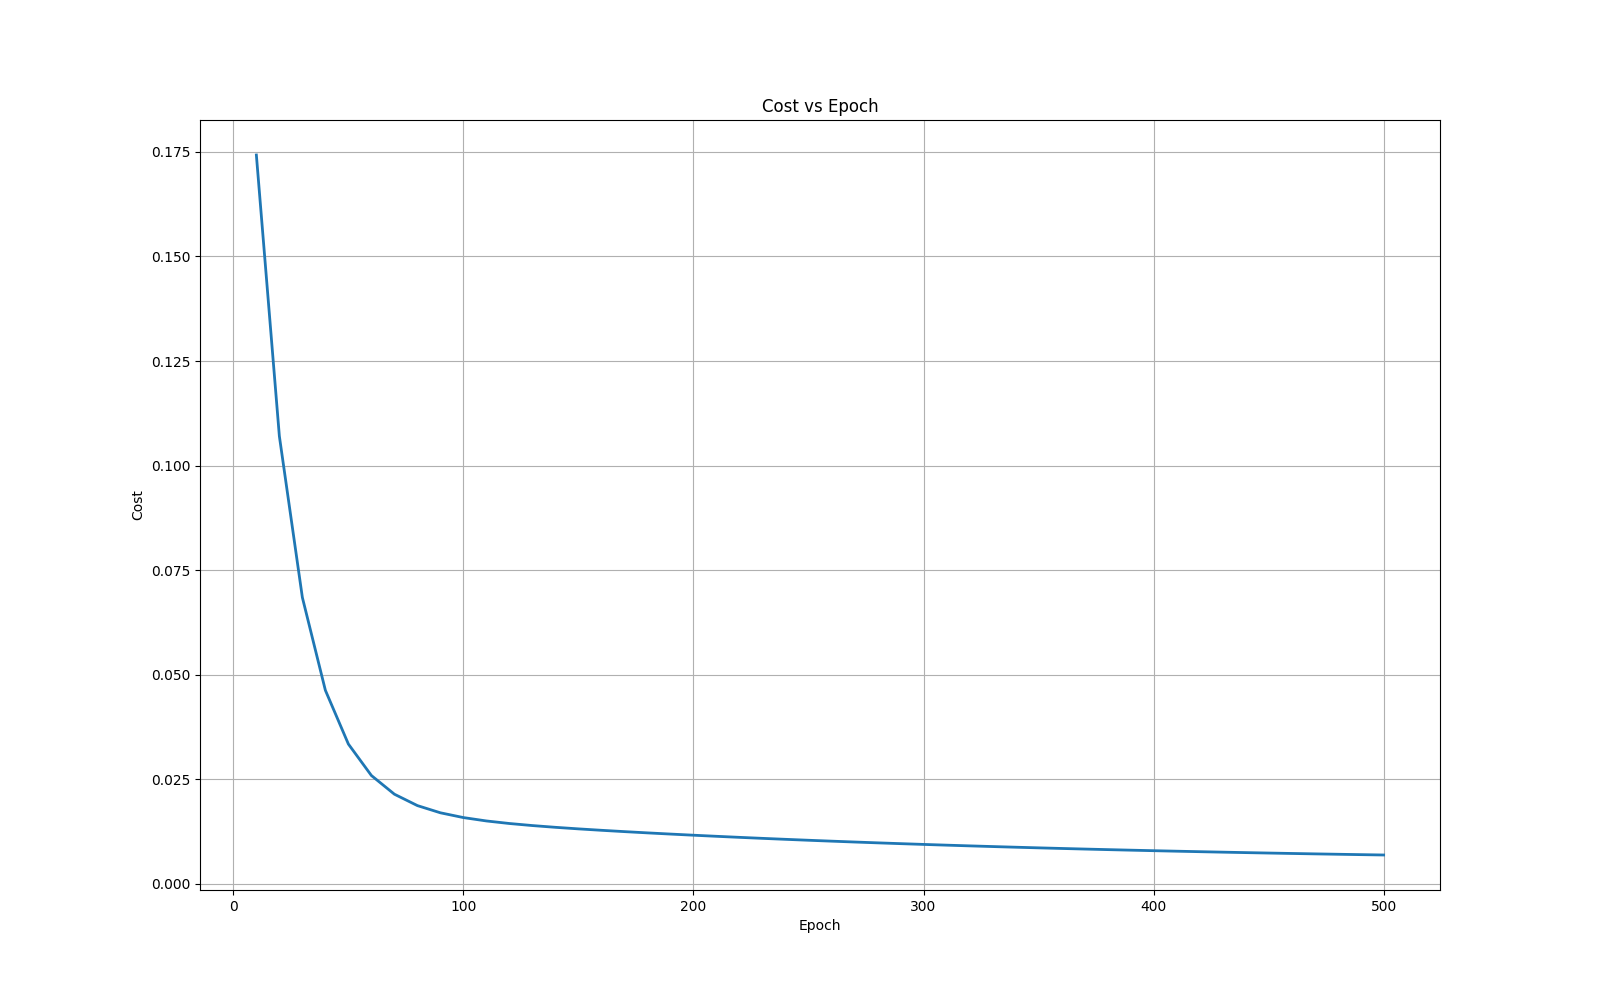

In [83]:
plt.figure(figsize=(16,10))
plt.plot(epoch_list, cost_list, linewidth=2)

plt.title("Cost vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.grid(True)

plt.show()

Now for our prediction function:

In [71]:
def predict(area, bedrooms, w, b):
    new_scaled_X = x_scaler.transform([[area,bedrooms]])[0]

    scaled_price = w[0] * new_scaled_X[0] + w[1] * new_scaled_X[1] + b
    return y_scaler.inverse_transform([[scaled_price]])[0][0]

predict(2600,4,w,b)

c:\Users\udhay\OneDrive\Documents\University\Student_Teams\BIOM\TensorFlow_Practice\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


np.float64(128.45484403267596)

The predicted price is 128 compared to the real price of 200, which is not bad.

Now let us look at the code for *stochastic gradient descent*.

In [78]:
import random

# Implement the stochastic gradient descent
def stochastic_gradient_descent(X, y_true, epochs, learning_rate = 0.01):
    # Number of features/inputs/neurons in input layer
    number_of_features = X.shape[1]

    # kernel_initializer = 'ones'
    w = np.ones(shape=(number_of_features))
    # bias_initializer = 'zeros'
    bias = 0

    # Total number of samples
    total_number_of_samples = X.shape[0]

    # Used for graph later
    cost_list = []
    epochs_list = []

    for i in range(epochs):
        random_index = random.randint(0, total_number_of_samples-1)

        sample_x = X[random_index]
        sample_y = y_true[random_index]

        # Calculate the weighted sum
        y_predicted = np.dot(w, np.transpose(sample_x)) + bias

        # Values of derivatives of loss with respect to weights
        derivative_of_loss_with_respect_to_weights = -(2/total_number_of_samples)*(sample_x.T.dot(sample_y-y_predicted))
        derivative_of_loss_with_respect_to_bias = -(2/total_number_of_samples)*np.sum(sample_y-y_predicted)

        # Calculate new weights and bias (backpropagation)
        w = w - learning_rate * derivative_of_loss_with_respect_to_weights
        bias = bias - learning_rate * derivative_of_loss_with_respect_to_bias

        # Calculate the loss
        cost = np.mean(np.square(sample_y-y_predicted))

        # Log every ten iterations:
        if (i+1) % 10 == 0:
            cost_list.append(cost)
            epochs_list.append(i+1)

    return w, bias, cost, cost_list, epochs_list

w_sgd, b_sgd , cost_sgd, cost_list_sgd, epoch_list_sgd = stochastic_gradient_descent(scaled_X, scaled_y.reshape(scaled_y.shape[0],), 10000)
w_sgd, b_sgd, cost_sgd

(array([0.70531421, 0.67130071]),
 np.float64(-0.2268206823528966),
 np.float64(0.0039320883611589155))

As we can see, in SGD it takes more epoch to reach optimal weights and bias.

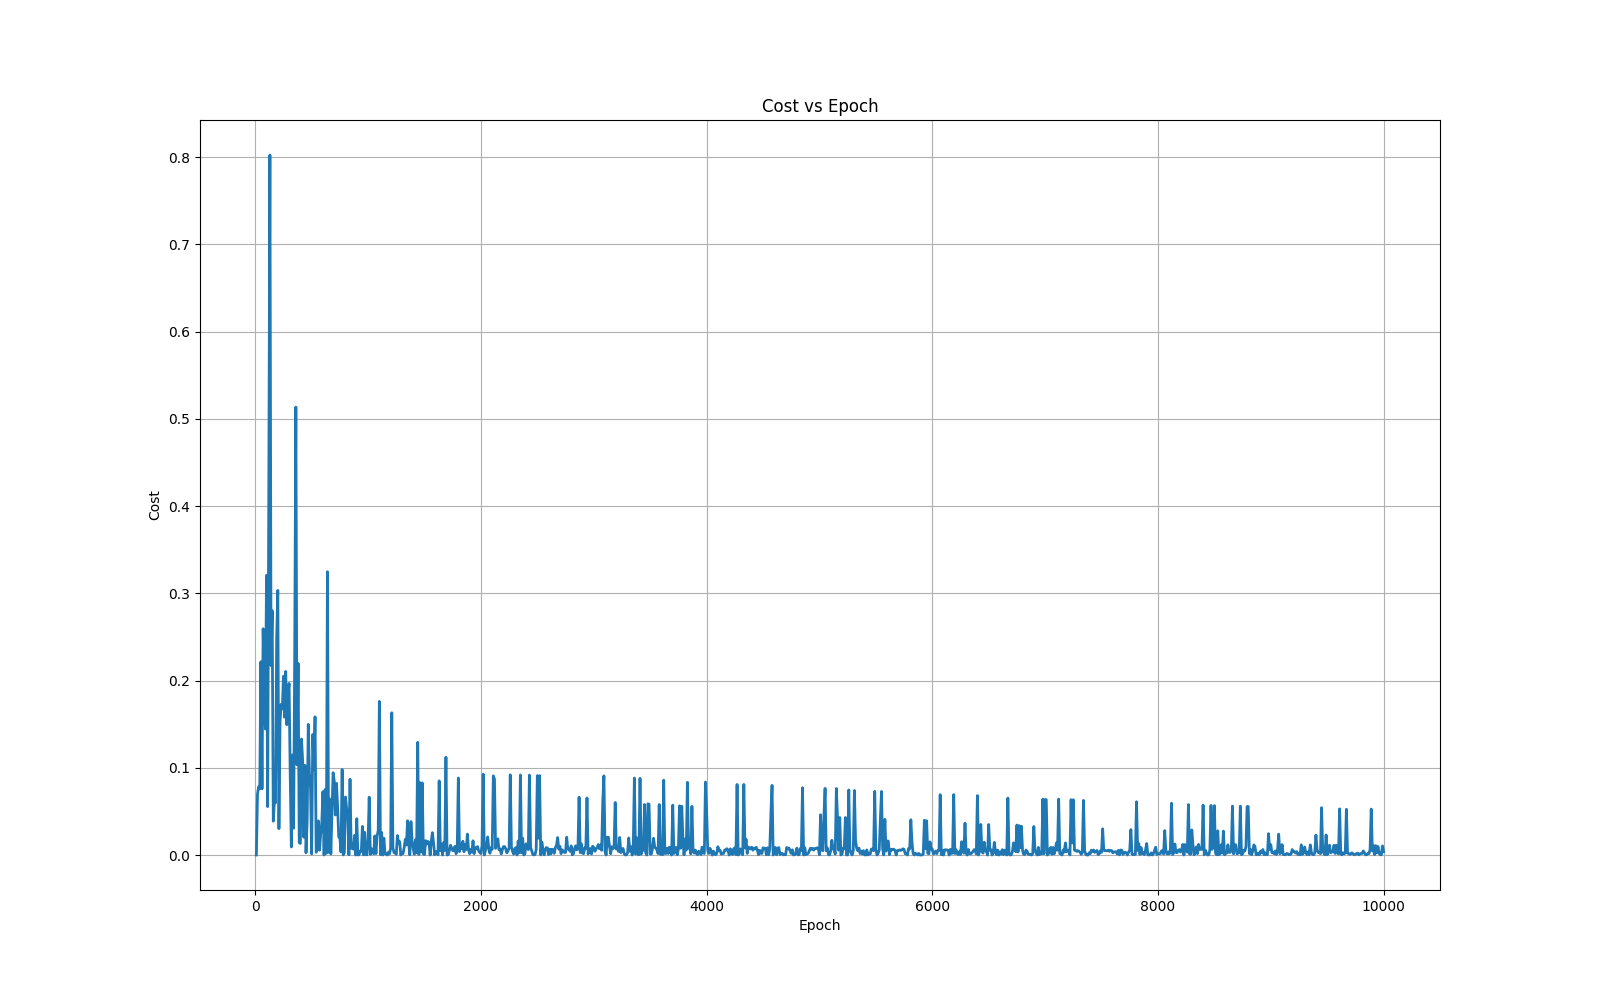

In [82]:
plt.figure(figsize=(16,10))
plt.plot(epoch_list_sgd, cost_list_sgd, linewidth=2)

plt.title("Cost vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.grid(True)

plt.show()

## Chain Rule and Neural Networks

Consider the dense neural network below:

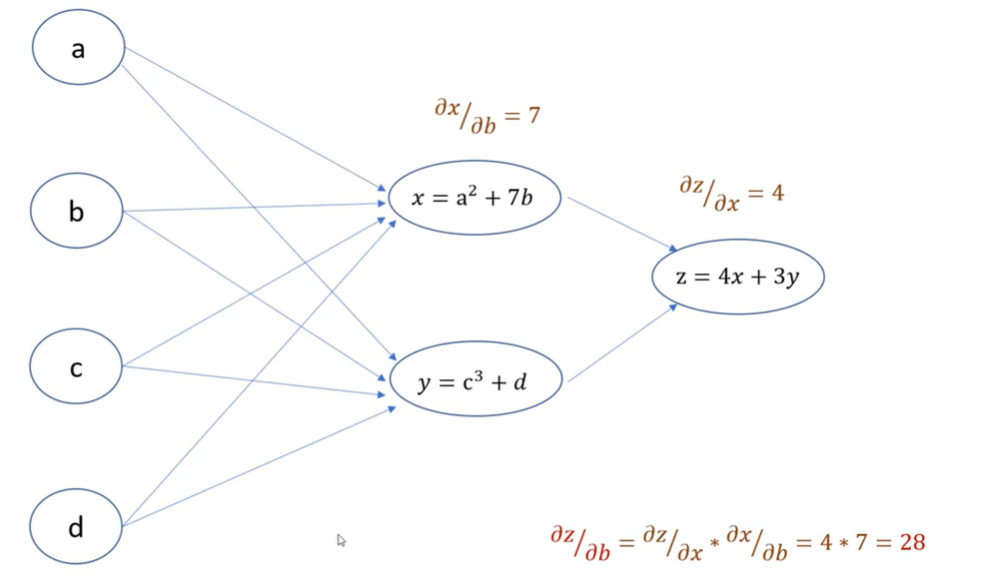

In [84]:
from IPython.display import Image, display
display(Image("./images/Dense_Neural_Network.png"))

As we can see above, this neural network has a hidden layer.

So the output variable z is not expressed directly in terms of the input features a, b, c and d. How can we backpropagate the loss to compute the rate of change of the loss with respect to each of the input features then? 

The answer to that is the **chain rule of differentiation**. In the above image, for example, to find the change in the cost per unit change in $w_b$, where $w_b$ is the weight of input b, we use the formula:

$$

\frac{dL}{dw_b} = \frac{dL}{de} \cdot \frac{de}{dz} \cdot \frac{dz}{dx} \cdot \frac{dx}{dw_b}

$$

where L is the cost of the epoch, e is the formula for the error produced in one forward pass and z is the predicted value.

*Note: Since y is independent of x,*

$$

\frac{dz}{dx} = 4 \cdot 3\frac{dy}{dx} = 4 \cdot 3*0 = 4

$$

Hence, this is how backpropagation is done across multiple layers in a neural network to adjust the weights and bias used in each layer.

## TensorBoard Introduction

Tensorboard is a tool that is useful in debugging the issues that happen with a neural network. It is also helpful in visualizing metrics such as accuracy. Since this is just a separate tool that can be used for debugging, we will skip it for now.

Below is a simple example how to use it in code:

In [96]:
import pandas as pd

df = pd.read_csv('./datasets/housing.csv')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# For simplicity, we are not doing any preprocessing
X, y = df.drop("MedHouseVal", axis=1), df["MedHouseVal"]

# Split the data
new_X_train, new_X_test, new_y_train, new_y_test = train_test_split(X, y,test_size=0.2)

# Scale the data
X_train_scaled = scaler.fit_transform(new_X_train)
X_test_scaled = scaler.fit_transform(new_X_test)

model = Sequential()
# Input layer
model.add(Input((8,)))
# Hidden layers
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))
# Output layer
model.add(Dense(1)) # We do not use softmax here as it will not make sense. Softmax is mostly used for classfication problems

# Creating the tensorboard callback
tb_callback = tf.keras.callbacks.TensorBoard(log_dir='logs/', histogram_freq=1)

model.compile(optimizer='adam', loss='mse', metrics=['mae', 'r2_score'])

model.fit(X_train_scaled, new_y_train, epochs=10, callbacks=[tb_callback])

Epoch 1/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.7279 - mae: 0.5775 - r2_score: 0.4494  
Epoch 2/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3881 - mae: 0.4397 - r2_score: 0.7065
Epoch 3/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3632 - mae: 0.4207 - r2_score: 0.7253
Epoch 4/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3388 - mae: 0.4103 - r2_score: 0.7437
Epoch 5/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3281 - mae: 0.3999 - r2_score: 0.7518
Epoch 6/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3297 - mae: 0.3963 - r2_score: 0.7507
Epoch 7/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3164 - mae: 0.3890 - r2_score: 0.7607
Epoch 8/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3185 - mae: 0.3837 - r2_score: 0.7591
Epoch 9/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.2954 - mae: 0.3781 - r2_score: 0.7766
Epoch 10/10
516/516 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2982 - mae: 0.3785 - r2_score: 0.77

Run the command:

> tensorboard --logdir logs/

to get the url where you can see the visualizations

*Note: Tensorboard will have issues running for Python 3.12+*

## Image Classification using ANN (Not CNN)

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# List devices present on device: CPU, GPU, etc...
tf.config.experimental.list_physical_devices()

# Test if TensorFlow version used supports CUDA
tf.test.is_built_with_cuda()

# Load the image dataset

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [103]:
# We have 50,000 32x32 images. The last dimension contains the RGB value of 
X_train.shape

(50000, 32, 32, 3)

In [ ]:
# Let us check some sample contents of y_train
y_train[0:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

Each number 0-9 corresponds to a unique class of image. The dataset has 10 classes of images. We can plot one of the images as shown below:

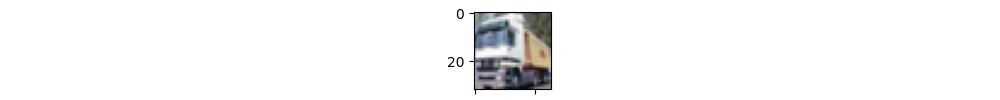

In [107]:
def plot_sample(index):
    plt.figure(figsize=(10,1))
    plt.imshow(X_train[index])

plot_sample(1)

So class 9 represents 'truck' which is consistent with the website. So let us declare the classes as a list where each index in the list corresponds to the number used to represent the class. 

In [108]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Scale the RGB values to make ANN more effective:

In [109]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

Now, we will perform one-hot encoding to represent each of the classes:

In [113]:
# Perform one-hot encoding on y_train
y_train_categorical = tf.keras.utils.to_categorical(
    y_train, num_classes=10
)

y_test_categorical = tf.keras.utils.to_categorical(
    y_test, num_classes=10
)

# Let us look at a sample
y_train_categorical[:5]

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

Now we build the model architecture:

In [115]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten

model = Sequential()

# Input layer
model.add(Input((32,32,3)))
model.add(Flatten())
# Hidden layers
model.add(Dense(3000, activation="relu"))
model.add(Dense(1000, activation="relu"))

# Output layer
model.add(Dense(10, activation="sigmoid"))


# We use SGD because our dataset is large
# We use categorical crossentropy as our loss function because our output are one-hot encoded vectors
model.compile(optimizer="SGD", loss="categorical_crossentropy", metrics=["accuracy"])

# Train the model
model.fit(X_train_scaled, y_train_categorical, epochs=50)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 39ms/step - accuracy: 0.3569 - loss: 1.8087
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 38ms/step - accuracy: 0.4266 - loss: 1.6234
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 39ms/step - accuracy: 0.4542 - loss: 1.5418
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.4752 - loss: 1.4837
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 54ms/step - accuracy: 0.4929 - loss: 1.4316
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.5137 - loss: 1.3872
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 54ms/step - accuracy: 0.5232 - loss: 1.3531
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 92s 59ms/step - accuracy: 0.5380 - loss: 1.3182
Epoch 9/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 92s 59ms/step - accuracy: 0.5498 - loss: 1.2833
Epoch 10/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 90s 58ms/step - accuracy: 0.5591 - loss: 1.2552
Epoch 11/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 91s 58ms/step - accuracy: 0.5718 - loss: 1.2230
Epoch 12

In [118]:
classes[np.argmax(model.predict(X_test_scaled)[0])]

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


'cat'

In [116]:
classes[y_test[0][0]]

'cat'

We have successfully trained our ANN for image classification. Let us evaluate it.